# Introduction

This notebook addresses the Machine Learning assignment based on the
Consumer Financial Protection Bureau (CFPB) consumer complaints dataset.
Meridian Financial Group is experiencing a sustained increase in customer
complaints across products such as mortgages, credit cards, loans, and
credit reporting. Senior executives are particularly concerned about the
subset of complaints that escalate into formal disputes, as these cases
carry higher regulatory, reputational, and customer‑churn risk.

The objective of this work is to transform raw complaint records into
actionable intelligence. First, I perform exploratory data analysis (Q1) to
quantify escalation patterns across products, submission channels, and
geographies and to extract managerial insights. Next, I frame the problem
as a supervised binary classification task (Q2) and develop two predictive
models to estimate whether a complaint will be disputed (0 = Not Disputed,
1 = Disputed), including feature engineering, preprocessing, and
hyperparameter tuning.

I then evaluate the models using metrics that are appropriate for an
imbalanced, risk‑sensitive setting (F1‑score and ROC‑AUC) and compare their
performance to select a model suitable for operational use (Q3). The chosen
model is saved as a reusable pipeline, together with a feature engineering
module and requirements file, and is validated on an external dataset to
ensure reproducibility and deployment readiness (Q4). Finally, I interpret
the most influential drivers of escalation and propose a concrete strategic
action that Meridian could implement to reduce escalation risk and improve
customer outcomes (Q5).

# Q1 - Exploratory Data Analysis

This section examines how complaint escalation varies across products, submission channels, and states before any predictive modeling is performed. The purpose is to validate management assumptions, detect risk concentrations, and define the operational context for dispute prediction.

From a business perspective, exploratory analysis is necessary because model outputs are only useful if they reflect real complaint-handling patterns. The results below identify where escalation pressure is highest and provide evidence for which variables should be prioritized in the prediction pipeline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
df = pd.read_csv("complaints_training.csv")

# 2. BASIC INSPECTION
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nTarget value counts (raw):")
print(df["Consumer disputed?"].value_counts(dropna=False))


Shape: (321430, 18)

Columns:
 ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Target value counts (raw):
Consumer disputed?
No     257436
Yes     63994
Name: count, dtype: int64


## Q1.A - Data Inspection

This section performs initial data inspection. The goal is to confirm data structure, quality, and target balance before any model-related steps.


In [2]:
# Safe copy for inspection and descriptive EDA only (does not affect training dataframe)
eda_df = df.copy()

print(f"Dataset shape: {eda_df.shape[0]:,} rows x {eda_df.shape[1]} columns")

print()
print("Column list:")
print(eda_df.columns.tolist())

print()
print("Preview (first 5 rows):")
display(eda_df.head())

print()
print("Data types:")
display(eda_df.dtypes.rename("dtype").to_frame())


Dataset shape: 321,430 rows x 18 columns

Column list:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Preview (first 5 rows):


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2015-12-17,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,Ocwen Financial Corporation,ME,04419,"Older American, Servicemember",NaN,Referral,2015-12-23,Closed with explanation,Yes,Yes,1705202
1,2015-05-27,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,Company chooses not to provide a public response,WELLS FARGO & COMPANY,FL,33615,Servicemember,NaN,Referral,2015-05-29,Closed with explanation,Yes,No,1394282
2,2015-07-13,Mortgage,FHA mortgage,"Loan modification,collection,foreclosure",NaN,I have filed numerous complaints in an attempt...,NaN,NATIONSTAR MORTGAGE LLC,NC,27520,NaN,Consent provided,Web,2015-07-14,Closed with explanation,Yes,No,1466066
3,2015-12-18,Debt collection,"Other (i.e. phone, health club, etc.)",Communication tactics,Frequent or repeated calls,NaN,NaN,SECURITY FINANCE CORP,LA,70508,NaN,Consent not provided,Web,2015-12-21,Closed with explanation,Yes,No,1702559
4,2015-03-04,Bank account or service,Checking account,"Making/receiving payments, sending money",NaN,NaN,NaN,WELLS FARGO & COMPANY,CT,06460,NaN,NaN,Referral,2015-03-11,Closed with explanation,Yes,No,1267075



Data types:


,dtype
Date received,str
Product,str
Sub-product,str
Issue,str
Sub-issue,str
Consumer complaint narrative,str
Company public response,str
Company,str
State,str
ZIP code,str


In [3]:
# Missing values, duplicates, target distribution, and cardinality summary
missing_summary = (
    eda_df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(eda_df) * 100).round(2)

print("Missing values summary (top 15):")
display(missing_summary.head(15))

duplicate_count = eda_df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

target_col = "Consumer disputed?"
if target_col in eda_df.columns:
    target_dist = (
        eda_df[target_col]
        .value_counts(dropna=False)
        .rename_axis(target_col)
        .reset_index(name="count")
    )
    target_dist["pct"] = (target_dist["count"] / len(eda_df) * 100).round(2)
    print()
    print("Target distribution:")
    display(target_dist)

key_cat_cols = ["Product", "Issue", "Submitted via", "State", "Company"]
available_key_cols = [c for c in key_cat_cols if c in eda_df.columns]

cardinality = pd.DataFrame({
    "column": available_key_cols,
    "n_unique": [eda_df[c].nunique(dropna=True) for c in available_key_cols],
    "missing": [eda_df[c].isna().sum() for c in available_key_cols],
    "top_value": [eda_df[c].mode(dropna=True).iloc[0] if not eda_df[c].mode(dropna=True).empty else np.nan for c in available_key_cols],
    "top_value_count": [eda_df[c].value_counts(dropna=True).iloc[0] if not eda_df[c].value_counts(dropna=True).empty else 0 for c in available_key_cols],
})

print()
print("Cardinality summary for key categorical columns:")
display(cardinality.sort_values("n_unique", ascending=False))


Missing values summary (top 15):


,missing_count,missing_pct
Tags,272731,84.85
Consumer complaint narrative,266691,82.97
Company public response,259597,80.76
Consumer consent provided?,221797,69.00
Sub-issue,170355,53.00
Sub-product,98075,30.51
State,2145,0.67
ZIP code,1363,0.42
Product,0,0.00
Date received,0,0.00


Duplicate rows: 0

Target distribution:


,Consumer disputed?,count,pct
0,No,257436,80.09
1,Yes,63994,19.91



Cardinality summary for key categorical columns:


,column,n_unique,missing,top_value,top_value_count
4,Company,3250,0,"EQUIFAX, INC.",21966
1,Issue,92,0,Incorrect information on credit report,47051
3,State,62,2145,CA,45252
0,Product,12,0,Mortgage,85296
2,Submitted via,6,0,Web,230522


The inspection confirms dataset scale, column structure, and data quality characteristics relevant for escalation modeling. In business terms, target imbalance and high-cardinality categories indicate that dispute prediction must rely on robust preprocessing and careful model evaluation rather than raw accuracy.


## Q1.B - Exploratory Data Analysis




### 1) Executive assumption test: digital vs non-digital submission channels


,channel_group,complaint_count,dispute_rate
0,Digital,230547,21.60
1,Non-digital,90883,15.62


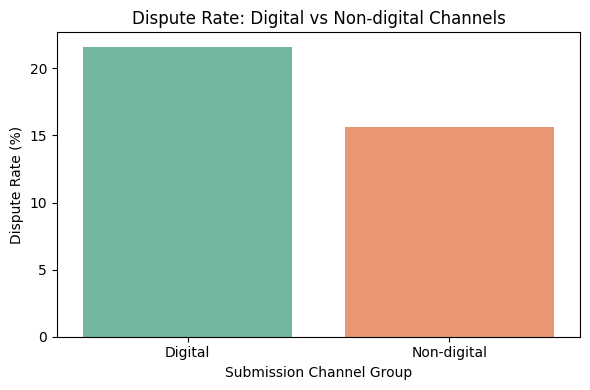

In [4]:
eda_channels = eda_df.copy()
eda_channels["disputed_flag"] = eda_channels["Consumer disputed?"].map({"Yes": 1, "No": 0})

# Group channels into digital vs non-digital using clear keyword logic
digital_keywords = ["web", "email", "online", "mobile"]
eda_channels["channel_text"] = eda_channels["Submitted via"].astype(str).str.lower()
eda_channels["channel_group"] = np.where(
    eda_channels["channel_text"].str.contains("|".join(digital_keywords), na=False),
    "Digital",
    "Non-digital"
)

channel_comp = (
    eda_channels.dropna(subset=["disputed_flag"])
    .groupby("channel_group")["disputed_flag"]
    .agg(complaint_count="count", dispute_rate="mean")
    .reset_index()
)
channel_comp["dispute_rate"] = (channel_comp["dispute_rate"] * 100).round(2)

display(channel_comp)

plt.figure(figsize=(6, 4))
sns.barplot(data=channel_comp, x="channel_group", y="dispute_rate", hue="channel_group", dodge=False, legend=False, palette="Set2")
plt.title("Dispute Rate: Digital vs Non-digital Channels")
plt.xlabel("Submission Channel Group")
plt.ylabel("Dispute Rate (%)")
plt.tight_layout()
plt.show()


This comparison tests whether channel experience is associated with escalation. If digital channels show higher dispute rates, the business implication is that self-service intake may need stronger guidance and early support to prevent complaint escalation.


### 2) Product-level dispute rate


,Product,complaint_count,dispute_rate
6,Mortgage,85296,23.65
1,Consumer Loan,13336,22.62
2,Credit card,31274,21.31
0,Bank account or service,31802,19.70
10,Student loan,8783,19.45
7,Other financial service,428,18.69
4,Debt collection,78794,18.46
3,Credit reporting,63510,16.30
8,Payday loan,3291,15.86
5,Money transfers,2788,13.88


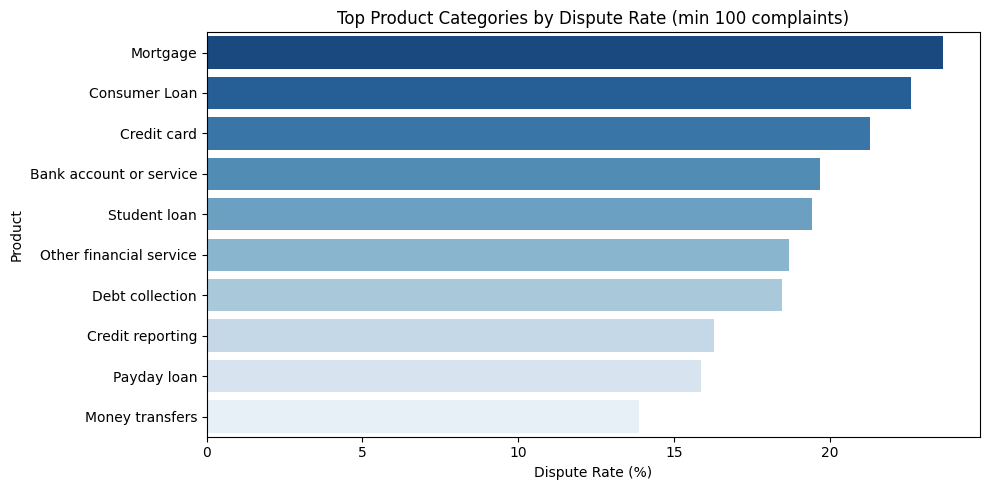

In [5]:
eda_product = eda_df.copy()
eda_product["disputed_flag"] = eda_product["Consumer disputed?"].map({"Yes": 1, "No": 0})

product_summary = (
    eda_product.dropna(subset=["disputed_flag"])
    .groupby("Product")["disputed_flag"]
    .agg(complaint_count="count", dispute_rate="mean")
    .reset_index()
)

# Keep products with reasonable support for stable rates
product_summary = product_summary[product_summary["complaint_count"] >= 100].copy()
product_summary["dispute_rate"] = (product_summary["dispute_rate"] * 100).round(2)
product_top = product_summary.sort_values("dispute_rate", ascending=False).head(10)

display(product_top)

plt.figure(figsize=(10, 5))
sns.barplot(data=product_top, x="dispute_rate", y="Product", hue="Product", dodge=False, legend=False, palette="Blues_r")
plt.title("Top Product Categories by Dispute Rate (min 100 complaints)")
plt.xlabel("Dispute Rate (%)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


Product-level variation highlights where escalation risk is structurally higher. From a business perspective, high-rate product groups should receive prioritized quality controls, specialist handling, and earlier intervention.


### 3) State-level complaint volume and dispute rate (top states only)


,State,complaint_count,dispute_rate
8,CA,45252,21.53
13,FL,30599,19.90
53,TX,26448,17.63
42,NY,21674,19.04
15,GA,13812,19.41
39,NJ,12849,19.50
46,PA,11761,19.16
20,IL,11497,21.27
55,VA,10794,20.84
43,OH,10128,19.38


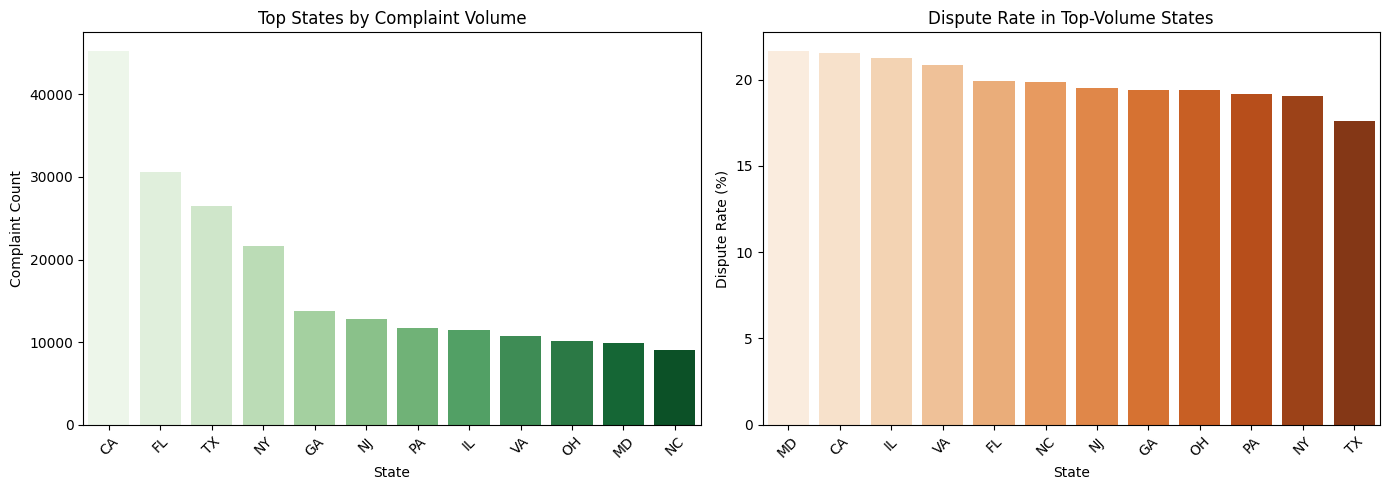

In [6]:
eda_state = eda_df.copy()
eda_state["disputed_flag"] = eda_state["Consumer disputed?"].map({"Yes": 1, "No": 0})

state_summary = (
    eda_state.dropna(subset=["State", "disputed_flag"])
    .groupby("State")["disputed_flag"]
    .agg(complaint_count="count", dispute_rate="mean")
    .reset_index()
)
state_summary["dispute_rate"] = (state_summary["dispute_rate"] * 100).round(2)

top_states = state_summary.sort_values("complaint_count", ascending=False).head(12)

display(top_states)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top_states.sort_values("complaint_count", ascending=False),
            x="State", y="complaint_count", hue="State", dodge=False, legend=False, ax=axes[0], palette="Greens")
axes[0].set_title("Top States by Complaint Volume")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Complaint Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=top_states.sort_values("dispute_rate", ascending=False),
            x="State", y="dispute_rate", hue="State", dodge=False, legend=False, ax=axes[1], palette="Oranges")
axes[1].set_title("Dispute Rate in Top-Volume States")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Dispute Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


Showing top-volume states keeps the analysis readable while focusing on operationally material regions. Differences in volume and dispute rate help identify where localized process improvements can produce the largest impact.


### 4) Complaint timing exploration using `Date received`


,month,complaint_count
12,2015-01,12625
13,2015-02,12679
14,2015-03,14508
15,2015-04,13747
16,2015-05,13678
17,2015-06,14515
18,2015-07,15914
19,2015-08,15763
20,2015-09,14331
21,2015-10,14891


,weekday,complaint_count
0,Monday,52465
1,Tuesday,60522
2,Wednesday,62914
3,Thursday,59981
4,Friday,52520
5,Saturday,19087
6,Sunday,13941


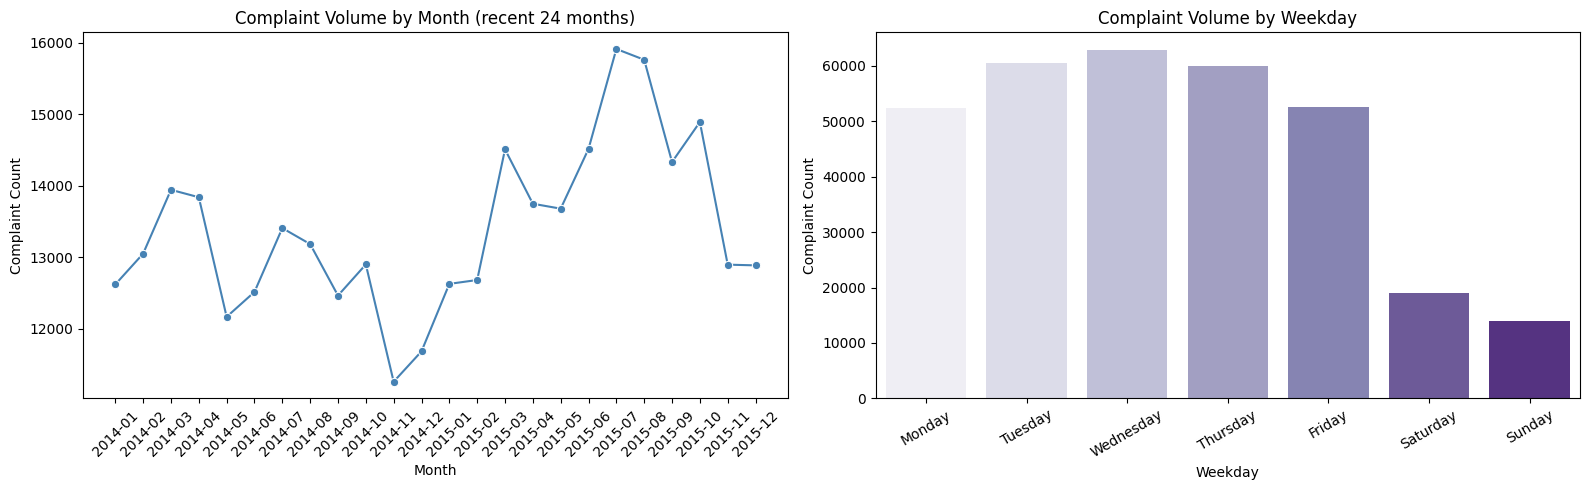

In [7]:
eda_time = eda_df.copy()
eda_time["Date received"] = pd.to_datetime(eda_time["Date received"], errors="coerce")

monthly_volume = (
    eda_time.dropna(subset=["Date received"])
    .assign(month=lambda d: d["Date received"].dt.to_period("M").astype(str))
    .groupby("month")
    .size()
    .rename("complaint_count")
    .reset_index()
)

# Keep recent months for concise plotting
monthly_plot = monthly_volume.tail(24)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_volume = (
    eda_time.dropna(subset=["Date received"])
    .assign(weekday=lambda d: d["Date received"].dt.day_name())
    .groupby("weekday")
    .size()
    .reindex(weekday_order)
    .fillna(0)
    .rename("complaint_count")
    .reset_index()
)

display(monthly_plot.tail(12))
display(weekday_volume)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=monthly_plot, x="month", y="complaint_count", marker="o", ax=axes[0], color="steelblue")
axes[0].set_title("Complaint Volume by Month (recent 24 months)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Complaint Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=weekday_volume, x="weekday", y="complaint_count", hue="weekday", dodge=False, legend=False, ax=axes[1], palette="Purples")
axes[1].set_title("Complaint Volume by Weekday")
axes[1].set_xlabel("Weekday")
axes[1].set_ylabel("Complaint Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


Timing patterns indicate when complaint demand peaks and where service staffing pressure may occur. In escalation management, predictable surges can inform capacity planning to reduce response delays that may contribute to dispute risk.


### 5) Narrative exploration (descriptive only)


,disputed_flag,complaint_count,narrative_presence_rate,median_narrative_length,mean_narrative_length
0,Not Disputed,257436,16.25,0.0,160.1
1,Disputed,63994,20.17,0.0,243.3


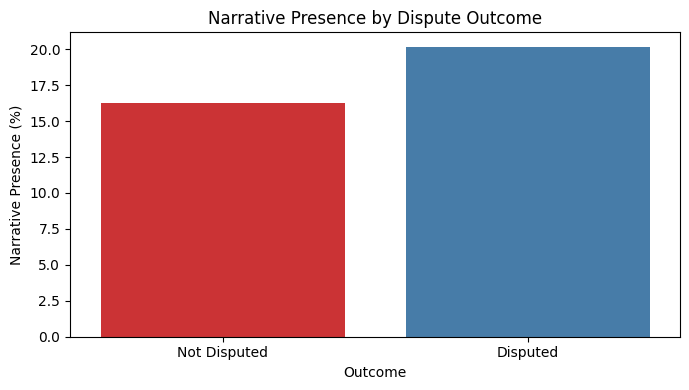

In [8]:
eda_narr = eda_df.copy()
eda_narr["disputed_flag"] = eda_narr["Consumer disputed?"].map({"Yes": 1, "No": 0})

narr_col = "Consumer complaint narrative"
if narr_col in eda_narr.columns:
    eda_narr["has_narrative"] = eda_narr[narr_col].notna() & (eda_narr[narr_col].astype(str).str.strip() != "")
    eda_narr["narrative_length"] = eda_narr[narr_col].fillna("").astype(str).str.len()

    narrative_summary = (
        eda_narr.dropna(subset=["disputed_flag"])
        .groupby("disputed_flag")
        .agg(
            complaint_count=("disputed_flag", "count"),
            narrative_presence_rate=("has_narrative", "mean"),
            median_narrative_length=("narrative_length", "median"),
            mean_narrative_length=("narrative_length", "mean"),
        )
        .reset_index()
    )
    narrative_summary["disputed_flag"] = narrative_summary["disputed_flag"].map({0: "Not Disputed", 1: "Disputed"})
    narrative_summary["narrative_presence_rate"] = (narrative_summary["narrative_presence_rate"] * 100).round(2)
    narrative_summary["mean_narrative_length"] = narrative_summary["mean_narrative_length"].round(1)

    display(narrative_summary)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=narrative_summary, x="disputed_flag", y="narrative_presence_rate", hue="disputed_flag", dodge=False, legend=False, palette="Set1")
    plt.title("Narrative Presence by Dispute Outcome")
    plt.xlabel("Outcome")
    plt.ylabel("Narrative Presence (%)")
    plt.tight_layout()
    plt.show()

else:
    print(f"Column '{narr_col}' not found; narrative exploration skipped.")


Narrative features are reviewed descriptively to understand communication patterns, not to claim causality. Differences by dispute outcome can help frame how customer expression and case complexity may relate to escalation behavior.


#### 3. ENCODE TARGET
#### Convert 'Yes'/'No' to 1/0 for easier analysis

In [9]:
# 3. ENCODE TARGET
# Convert 'Yes'/'No' to 1/0 for easier analysis
df["disputed"] = df["Consumer disputed?"].map({"Yes": 1, "No": 0})

print("Class balance (%):")
print(df["disputed"].value_counts(normalize=True).mul(100).round(1))

Class balance (%):
disputed
0    80.1
1    19.9
Name: proportion, dtype: float64


#### 4. Q1.1 — ASSUMPTION 1: Do certain products escalate more?

In [10]:
# 4. Q1.1 — ASSUMPTION 1: Do certain products escalate more?
product_escalation = (
    df.groupby("Product")["disputed"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "escalation_rate", "count": "total_complaints"})
    .sort_values("escalation_rate", ascending=False)
)
product_escalation["escalation_rate"] = product_escalation["escalation_rate"].mul(100).round(1)
print(product_escalation)

                         escalation_rate  total_complaints
Product                                                   
Virtual currency                    62.5                 8
Mortgage                            23.6             85296
Consumer Loan                       22.6             13336
Credit card                         21.3             31274
Bank account or service             19.7             31802
Student loan                        19.4              8783
Other financial service             18.7               428
Debt collection                     18.5             78794
Credit reporting                    16.3             63510
Payday loan                         15.9              3291
Money transfers                     13.9              2788
Prepaid card                        13.1              2120


### 5. Q1.1 — ASSUMPTION 2: Do digital channels escalate more?

In [11]:
# 5. Q1.1 — ASSUMPTION 2: Do digital channels escalate more?
channel_escalation = (
    df.groupby("Submitted via")["disputed"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "escalation_rate", "count": "total_complaints"})
    .sort_values("escalation_rate", ascending=False)
)
channel_escalation["escalation_rate"] = channel_escalation["escalation_rate"].mul(100).round(1)
print(channel_escalation)

               escalation_rate  total_complaints
Submitted via                                   
Email                     40.0                25
Web                       21.6            230522
Fax                       21.2              4460
Referral                  16.2             45158
Phone                     14.5             20522
Postal mail               14.4             20743


### 6. Q1.1 — ASSUMPTION 3: Do top states differ in escalation rates?

In [12]:
# 6. Q1.1 — ASSUMPTION 3: Do top states differ in escalation rates?
state_escalation = (
    df.groupby("State")["disputed"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "escalation_rate", "count": "total_complaints"})
)
state_escalation["escalation_rate"] = state_escalation["escalation_rate"].mul(100).round(1)
# Filter to states with at least 500 complaints for reliability
state_escalation = state_escalation[state_escalation["total_complaints"] >= 500]
print(state_escalation.sort_values("escalation_rate", ascending=False).head(10))
print("...")
print(state_escalation.sort_values("escalation_rate", ascending=False).tail(10))

       escalation_rate  total_complaints
State                                   
ME                24.3              1089
MS                23.2              1638
HI                23.1              1182
DE                22.8              1721
CO                22.7              5505
OR                22.0              3914
MD                21.7              9841
NV                21.6              4233
CA                21.5             45252
IL                21.3             11497
...
       escalation_rate  total_complaints
State                                   
WV                18.4               868
PR                18.2              1022
OK                18.0              2284
LA                18.0              3371
ID                17.7              1124
AR                17.6              1451
TX                17.6             26448
IN                17.3              3669
IA                16.5              1360
NM                15.8              1629


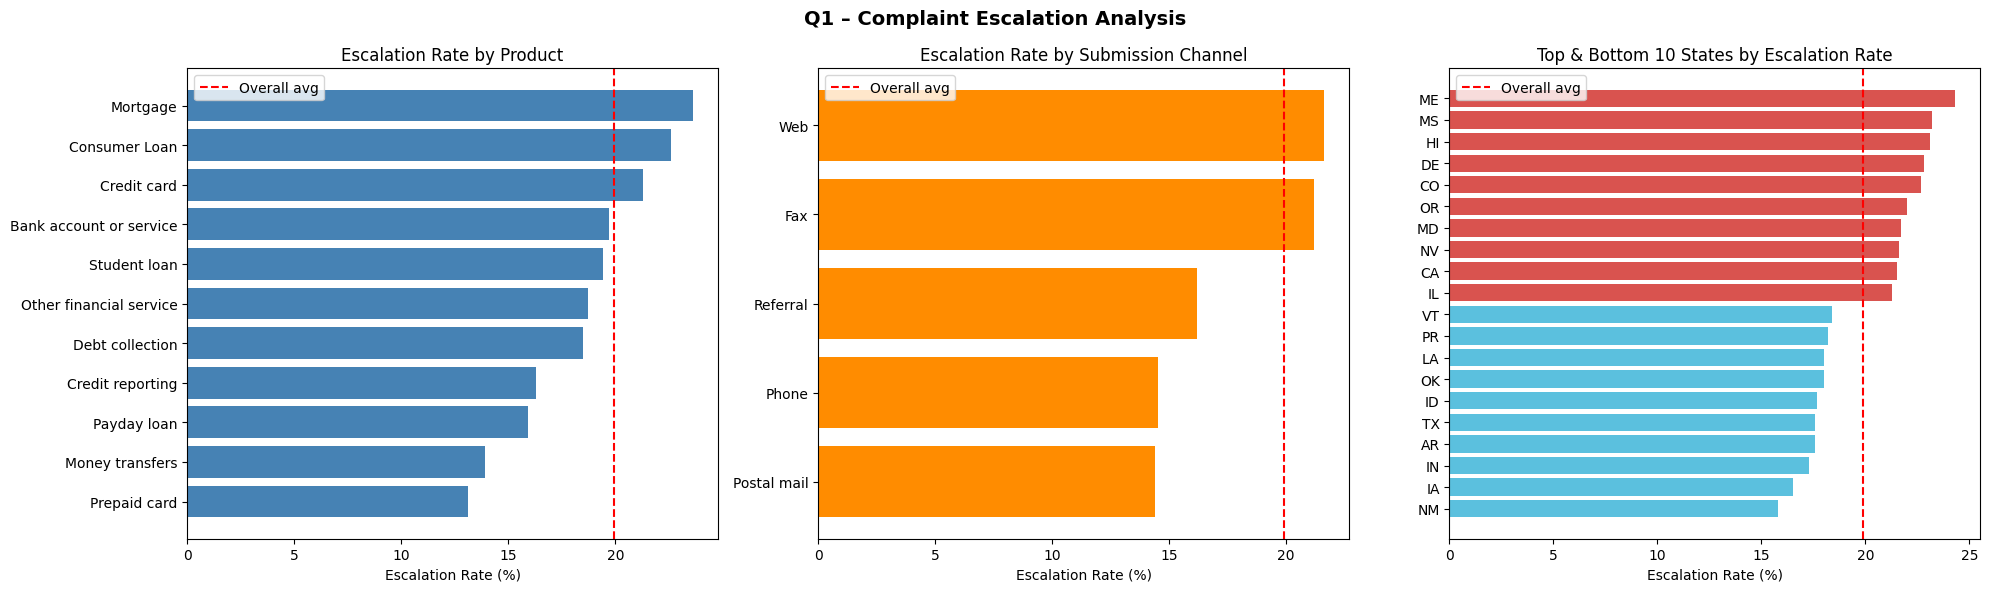

saved.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Q1 – Complaint Escalation Analysis", fontsize=14, fontweight='bold')

# CHART 1: Escalation Rate by Product (exclude Virtual currency)
product_plot = product_escalation[product_escalation["total_complaints"] >= 100].sort_values("escalation_rate")
axes[0].barh(product_plot.index, product_plot["escalation_rate"], color="steelblue")
axes[0].axvline(x=df["disputed"].mean() * 100, color="red", linestyle="--", label="Overall avg")
axes[0].set_xlabel("Escalation Rate (%)")
axes[0].set_title("Escalation Rate by Product")
axes[0].legend()

# CHART 2: Escalation Rate by Submission Channel (exclude Email)
channel_plot = channel_escalation[channel_escalation["total_complaints"] >= 100].sort_values("escalation_rate")
axes[1].barh(channel_plot.index, channel_plot["escalation_rate"], color="darkorange")
axes[1].axvline(x=df["disputed"].mean() * 100, color="red", linestyle="--", label="Overall avg")
axes[1].set_xlabel("Escalation Rate (%)")
axes[1].set_title("Escalation Rate by Submission Channel")
axes[1].legend()

# CHART 3: Top/Bottom 10 States by Escalation Rate
state_plot = state_escalation.sort_values("escalation_rate")
top_bottom = pd.concat([state_plot.head(10), state_plot.tail(10)])
colors = ["#d9534f" if x >= 21 else "#5bc0de" for x in top_bottom["escalation_rate"]]
axes[2].barh(top_bottom.index, top_bottom["escalation_rate"], color=colors)
axes[2].axvline(x=df["disputed"].mean() * 100, color="red", linestyle="--", label="Overall avg")
axes[2].set_xlabel("Escalation Rate (%)")
axes[2].set_title("Top & Bottom 10 States by Escalation Rate")
axes[2].legend()

plt.tight_layout()
plt.savefig("q1_escalation_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved.")

## Q1.1 - Testing Executive Assumptions

The plots and summary tables above test whether digital intake channels are associated with higher escalation to dispute. This test matters because channel strategy is directly controllable through service design and process support.

The evidence partially supports the assumption. Web-submitted complaints show an escalation rate of 21.6%, compared with 14.5% for Phone and 14.4% for Postal mail, a gap of about 7 percentage points. However, the pattern is not purely digital versus traditional: Fax (21.2%) is also high, while Referral (16.2%) is intermediate. A more precise interpretation is that self-service channels (Web, Fax) escalate more than assisted channels (Phone, Postal mail, Referral), suggesting that customers with less guided support are more likely to dispute outcomes.

For dispute prediction, this confirms that submission channel carries signal and should remain a core explanatory feature in the modeling stage.


## Q1.2 - Three Business Insights

The EDA results identify three actionable escalation patterns. First, Mortgage and Consumer Loan complaints show the highest escalation rates (23.6% and 22.6%), nearly 10 percentage points above lower-risk categories such as Prepaid Cards (13.1%). This indicates where specialist complaint-resolution capacity should be concentrated.

Second, the Web channel is both high volume and high risk: it represents 71.7% of all complaints (230,522 of 321,430) and has a 21.6% escalation rate. Because of this combination, even modest process improvements in web handling can produce large absolute reductions in disputed cases.

Third, escalation varies materially by state. Maine (24.3%) and Mississippi (23.2%) are close to 9 points above New Mexico (15.8%), which suggests meaningful regional differences in operations, customer experience, or compliance execution.

Together, these findings motivate a prediction approach focused on product type, channel, geography, and response process variables to identify complaints most likely to escalate.


# Q2 - Predictive Modelling

This section builds the dispute prediction pipeline using supervised binary classification (0 = Not Disputed, 1 = Disputed). The workflow includes feature engineering, train-test splitting, preprocessing for mixed data types, and model training with tuned hyperparameters.

The objective is not only statistical performance but operational usefulness: the model should help Meridian prioritize complaints that are most likely to escalate. Two model families are developed to balance interpretability and predictive flexibility, then evaluated on consistent criteria in Q3.


In [15]:
# Q2: FEATURE ENGINEERING & SELECTION
from feature_engineering import feature_engineering

# Apply importable feature engineering from feature_engineering.py
df_fe = feature_engineering(df)

# Features to use (drop high-cardinality or irrelevant columns)
features = [
    "Product",
    "Submitted via",
    "Company response to consumer",
    "Company public response",
    "Timely response?",
    "Tags",
    "Consumer consent provided?",
    "State",
    "days_to_respond"
]

target = "disputed"

# Build X and y from engineered dataset
X = df_fe[features].copy()
y = df_fe[target].copy()

print("X shape:", X.shape)
print("\nMissing values per column:")
print(X.isnull().sum())


X shape: (321430, 9)

Missing values per column:
Product                              0
Submitted via                        0
Company response to consumer         0
Company public response         259597
Timely response?                     0
Tags                            272731
Consumer consent provided?      221797
State                             2145
days_to_respond                      0
dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print("\nClass balance in train:")
print(y_train.value_counts(normalize=True).mul(100).round(1))

Train size: (257144, 9)
Test size:  (64286, 9)

Class balance in train:
disputed
0    80.1
1    19.9
Name: proportion, dtype: float64


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Separate column types
categorical_features = [
    "Product", "Submitted via", "Company response to consumer",
    "Company public response", "Timely response?",
    "Tags", "Consumer consent provided?", "State"
]
numerical_features = ["days_to_respond"]

# Categorical: fill missing with 'Unknown', then one-hot encode
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Numerical: fill missing with median
numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Combine both
preprocessor = ColumnTransformer([
    ("cat", categorical_transformer, categorical_features),
    ("num", numerical_transformer, numerical_features)
])

print("Preprocessor defined")

Preprocessor defined


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

categorical_features = [
    "Product", "Submitted via", "Company response to consumer",
    "Company public response", "Timely response?",
    "Tags", "Consumer consent provided?", "State"
]
numerical_features = ["days_to_respond"]

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))  # ← sparse=True saves RAM
])

numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("cat", categorical_transformer, categorical_features),
    ("num", numerical_transformer, numerical_features)
])

print("Preprocessor ready")

Preprocessor ready


In [19]:
from sklearn.model_selection import train_test_split

# Full split (keep this for final evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Smaller sample ONLY for hyperparameter tuning (50k rows, keeps class balance)
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    train_size=50000,
    random_state=42,
    stratify=y_train
)

print("Full train size:", X_train.shape)
print("Tuning sample size:", X_tune.shape)
print("Class balance in tuning sample:")
print(y_tune.value_counts(normalize=True).mul(100).round(1))

Full train size: (257144, 9)
Tuning sample size: (50000, 9)
Class balance in tuning sample:
disputed
0    80.1
1    19.9
Name: proportion, dtype: float64


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])

lr_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "saga"]
}

lr_search = RandomizedSearchCV(
    lr_pipeline, lr_params,
    n_iter=4, cv=3, scoring="f1",   # ← only 4 iterations
    random_state=42, n_jobs=-1, verbose=1
)

lr_search.fit(X_tune, y_tune)   # ← tune on small sample
print("Best LR params:", lr_search.best_params_)
print("Best LR CV F1:", round(lr_search.best_score_, 4))

# Refit best model on FULL training data
best_lr = lr_search.best_estimator_
best_lr.fit(X_train, y_train)
print("LR refitted on full training data")

Fitting 3 folds for each of 4 candidates, totalling 12 fits


c:\Users\divak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best LR params: {'model__solver': 'saga', 'model__C': 0.01}
Best LR CV F1: 0.3603
LR refitted on full training data


c:\Users\divak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


##### Some Logistic Regression configurations reached the maximum iteration limit during tuning, which can occur when one-hot encoding produces a very large feature space. Even so, the cross-validation process completed and model comparison was still based on F1 performance. For that reason, the model results remain suitable for comparison, although detailed coefficient interpretation should be approached carefully.

##### **Computational design note:** To reduce runtime and memory demands, hyperparameter tuning was performed on a smaller stratified subset of the training data while maintaining the original class balance. Once the best settings were identified, each model was retrained on the full training dataset so that final evaluation used all available information.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        n_estimators=100,    # ← fixed, no need to tune this
        max_features="sqrt"  # ← reduces memory per tree
    ))
])

rf_params = {
    "model__max_depth": [10, 20],       # ← only 2 options
    "model__min_samples_leaf": [5, 10]  # ← only 2 options
}

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_params,
    n_iter=4, cv=2, scoring="f1",   # ← cv=2 instead of 3 (saves 33% time)
    random_state=42, n_jobs=-1, verbose=1
)

rf_search.fit(X_tune, y_tune)   # ← tune on small sample
print("Best RF params:", rf_search.best_params_)
print("Best RF CV F1:", round(rf_search.best_score_, 4))

# Refit best model on FULL training data
best_rf = rf_search.best_estimator_
best_rf.fit(X_train, y_train)
print("RF refitted on full training data")

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best RF params: {'model__min_samples_leaf': 10, 'model__max_depth': 10}
Best RF CV F1: 0.3619
RF refitted on full training data


### Choice of models: Logistic Regression and Random Forest

Logistic Regression is used as a transparent baseline because it is computationally efficient, stable, and easy to communicate to non-technical stakeholders. It provides a clear reference point for whether added model complexity produces meaningful gains in dispute detection.

Random Forest is included as a non-linear alternative that can capture interactions between complaint attributes (for example, product, response type, channel, and state) without extensive manual feature construction. It is also robust for mixed tabular data and supports feature-importance analysis used later in Q5.

Using both models creates a defensible comparison framework: one prioritizes interpretability, the other prioritizes flexible pattern capture. The deployment choice is based on empirical risk-detection performance in Q3.


# Q3 - Model Evaluation

This section evaluates both trained models on the held-out test set using metrics aligned with class imbalance and business risk. The goal is to determine which model better supports early identification of complaints likely to escalate into disputes.

Interpretation focuses on operational consequences, not just numerical scores: how many high-risk complaints are captured, how many are missed, and how reliably each model ranks risk for downstream triage decisions.


In [24]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predictions
lr_preds  = best_lr.predict(X_test)
rf_preds  = best_rf.predict(X_test)
lr_proba  = best_lr.predict_proba(X_test)[:, 1]
rf_proba  = best_rf.predict_proba(X_test)[:, 1]

# Scores
print("=" * 45)
print("LOGISTIC REGRESSION")
print("=" * 45)
print(classification_report(y_test, lr_preds, target_names=["Not Disputed", "Disputed"]))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

print("\n" + "=" * 45)
print("RANDOM FOREST")
print("=" * 45)
print(classification_report(y_test, rf_preds, target_names=["Not Disputed", "Disputed"]))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

Not Disputed       0.86      0.51      0.64     51487
    Disputed       0.25      0.66      0.36     12799

    accuracy                           0.54     64286
   macro avg       0.55      0.58      0.50     64286
weighted avg       0.73      0.54      0.58     64286

ROC-AUC: 0.6093

RANDOM FOREST
              precision    recall  f1-score   support

Not Disputed       0.86      0.46      0.60     51487
    Disputed       0.25      0.71      0.36     12799

    accuracy                           0.51     64286
   macro avg       0.55      0.58      0.48     64286
weighted avg       0.74      0.51      0.55     64286

ROC-AUC: 0.6123


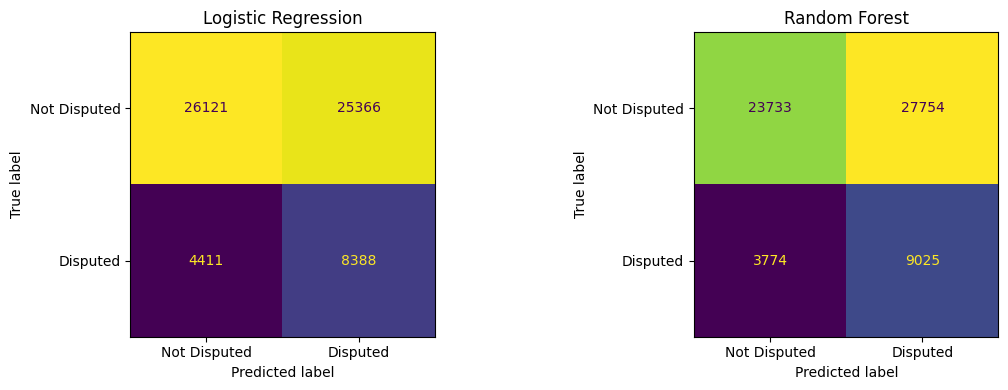

Confusion matrices saved ✓


In [25]:
# Confusion Matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, lr_preds),
    display_labels=["Not Disputed","Disputed"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(confusion_matrix(y_test, rf_preds),
    display_labels=["Not Disputed","Disputed"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.savefig("q3_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrices saved ✓")

## Q3.1 - Evaluation Metric Selection

Accuracy is not appropriate in this setting because the target is imbalanced (about 80% Not Disputed, 20% Disputed). A naive model that predicts only the majority class would appear strong on accuracy while failing to identify the disputed cases that matter most to the business.

The primary metric is F1-score for the disputed class because it balances precision and recall. This is the right trade-off for complaint escalation: false negatives (missed disputes) increase regulatory and reputational exposure, while false positives mainly increase review workload.

ROC-AUC is used as a secondary metric to assess ranking quality across thresholds. This supports deployment flexibility, since Meridian can later adjust intervention thresholds based on capacity and risk appetite without retraining the model.


## Q3.2 - Model Comparison and Deployment Decision

| Metric                    | Logistic Regression | Random Forest |
|---------------------------|---------------------|---------------|
| Disputed F1               | 0.36                | 0.36          |
| Disputed Recall           | 0.66                | **0.71**      |
| Disputed Precision        | 0.25                | 0.25          |
| ROC-AUC                   | 0.6093              | **0.6123**    |
| True Positives (disputes caught) | 8,388        | **9,025**     |
| False Negatives (missed disputes) | 4,411       | **3,774**     |

Random Forest is selected for deployment. Although both models produce the same disputed-class F1 (0.36), Random Forest provides stronger recall and ROC-AUC, catches 637 additional true disputes, and misses fewer high-risk cases. In this assignment context, reducing missed disputes is a higher-priority business objective than maximizing precision.

The low precision (0.25) indicates the model should be used as a prioritization layer rather than an automated final decision. In practice, flagged complaints should move to targeted human review, and the operating threshold can be tuned to balance intervention capacity against missed-risk tolerance.


# Q4 - Saving and Reloading the Model

This section packages the final model for reproducible use outside the training notebook. The emphasis is deployment readiness: a single serialized pipeline, explicit dependency versions, and a standalone feature engineering module that can run consistently in validation or production contexts.


In [27]:
import pickle

# Save the best model pipeline
filename = "68206_Pipeline.pkl" 
with open(filename, "wb") as f:
    pickle.dump(best_rf, f)

print(f"Model saved as {filename}")

Model saved as 68206_Pipeline.pkl


In [28]:
from feature_engineering import feature_engineering

print("Using feature_engineering imported from feature_engineering.py")
print("Saved pipeline contains sklearn built-ins only.")


Using feature_engineering imported from feature_engineering.py
Saved pipeline contains sklearn built-ins only.


In [29]:
from pathlib import Path

student_number = "68206"
requirements_text = """numpy==2.4.2
pandas==3.0.1
scikit-learn==1.8.0
joblib==1.5.3
"""

requirements_path = Path(f"{student_number}_requirements.txt")
requirements_path.write_text(requirements_text, encoding="utf-8")
print(f"{requirements_path.name} saved")


68206_requirements.txt saved


### Q4 - Model saving, dependencies and external validation

The selected Random Forest pipeline, including preprocessing, is saved as `68206_Pipeline.pkl`. This ensures that the exact training-time transformations and classifier are preserved together and can be reused without rebuilding steps manually.

Runtime dependencies are pinned in `68206_requirements.txt`, and feature preparation logic is centralized in `feature_engineering.py`. This separation improves reproducibility and reduces implementation risk during external validation.

Model reloading and validation on the external dataset `complaints_modeltesting100.csv` are performed in a separate notebook: `68206_Validation_Notebook.ipynb`.

Final notebook filename: `68206_Complaints_Notebook.ipynb`. Collectively, these artifacts support consistent dispute prediction behavior across training, validation, and submission environments.


# Q5 - Insights and Recommendation

This section translates model outputs into managerial guidance. Rather than treating prediction as an endpoint, the goal is to identify controllable drivers of escalation and define a focused intervention strategy that can reduce future dispute volume.


In [30]:
# Extract feature names from the preprocessor
ohe = best_rf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_features = ohe.get_feature_names_out(
    ["Product", "Submitted via", "Company response to consumer",
     "Company public response", "Timely response?",
     "Tags", "Consumer consent provided?", "State"]
)
num_features = ["days_to_respond"]
all_features = list(cat_features) + num_features

importances = best_rf.named_steps["model"].feature_importances_
feature_importance = pd.Series(importances, index=all_features).sort_values(ascending=False)
feature_importance.head(20)

Company response to consumer_Closed with explanation            0.223001
Company response to consumer_Closed with non-monetary relief    0.119383
Submitted via_Web                                               0.082874
days_to_respond                                                 0.079028
Company response to consumer_Closed with monetary relief        0.062022
Product_Mortgage                                                0.057323
Product_Credit reporting                                        0.038743
Submitted via_Referral                                          0.029083
Consumer consent provided?_Consent provided                     0.027581
Product_Debt collection                                         0.027028
Submitted via_Phone                                             0.023084
Company response to consumer_Untimely response                  0.020853
Timely response?_Yes                                            0.019284
Submitted via_Postal mail                          

## Q5.1 - Factors that influence complaint escalation

The feature-importance output indicates that company response type is the strongest predictor of dispute escalation. Categories such as "Closed with explanation," "Closed with non-monetary relief," and "Closed with monetary relief" carry high importance, suggesting that perceived response quality strongly shapes whether consumers escalate.

Submission channel is also influential, with Web showing higher importance than assisted channels. This is consistent with the EDA pattern and reinforces the view that intake experience affects dispute probability.

Timing-related variables (`days_to_respond` and "Timely response?") appear among the top drivers, indicating that slower or untimely handling is associated with greater escalation risk. Product-level effects are also evident, with Mortgage, Credit reporting, and Debt collection contributing more signal than lower-risk product groups.

These results should be interpreted as relative predictive influence, not causal proof. Even so, they provide strong operational direction on where escalation-control effort is most likely to improve dispute outcomes.


## Q5.2 - Strategic action to reduce escalation risk

A practical recommendation is to implement a targeted early-intervention workflow for complaints with the model profile linked to higher dispute risk: high-risk products (Mortgage, Credit reporting, Debt collection), self-service intake (especially Web), response outcomes such as "Closed with explanation" or "Closed with non-monetary relief," and signals of delayed handling.

Operationally, these cases should be routed to a specialist resolution queue with tighter SLAs, stronger response-quality standards, and prioritized review using model risk scores. This keeps decision authority with human teams while using prediction to allocate attention where escalation risk is highest.

The expected business effect is fewer missed high-risk complaints, lower dispute escalation, and improved regulatory defensibility through earlier, more consistent intervention.
